In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('Wine.csv')

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


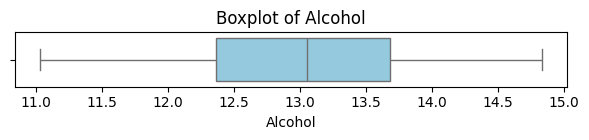

Column: Alcohol
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


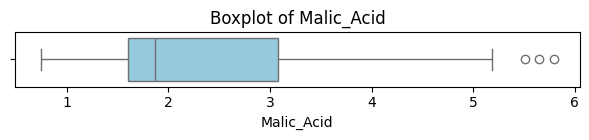

Column: Malic_Acid
IQR Method - Number of outliers: 3
Z-Score Method - Number of outliers: 1


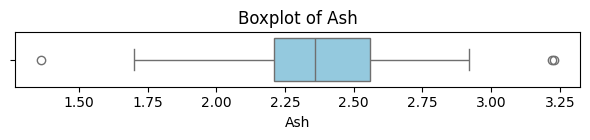

Column: Ash
IQR Method - Number of outliers: 3
Z-Score Method - Number of outliers: 3


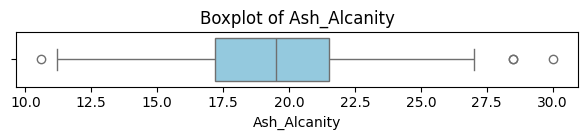

Column: Ash_Alcanity
IQR Method - Number of outliers: 4
Z-Score Method - Number of outliers: 1


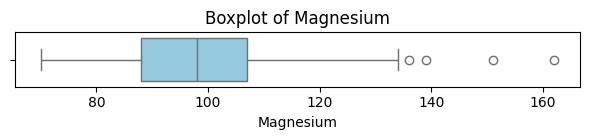

Column: Magnesium
IQR Method - Number of outliers: 4
Z-Score Method - Number of outliers: 2


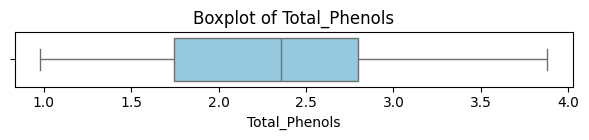

Column: Total_Phenols
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


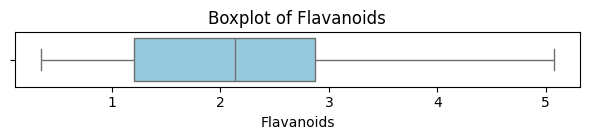

Column: Flavanoids
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 1


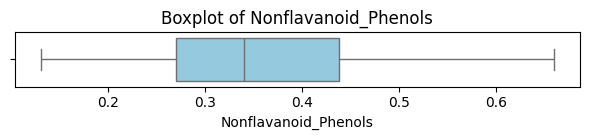

Column: Nonflavanoid_Phenols
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


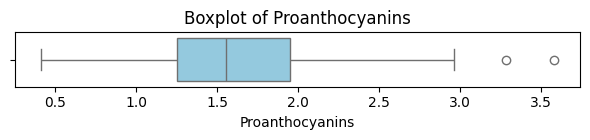

Column: Proanthocyanins
IQR Method - Number of outliers: 2
Z-Score Method - Number of outliers: 1


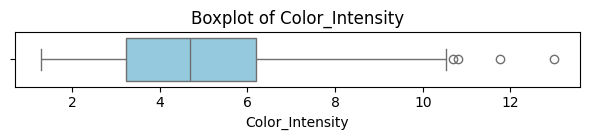

Column: Color_Intensity
IQR Method - Number of outliers: 4
Z-Score Method - Number of outliers: 1


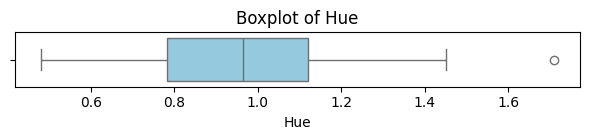

Column: Hue
IQR Method - Number of outliers: 1
Z-Score Method - Number of outliers: 1


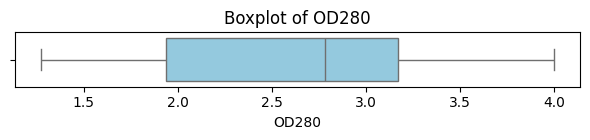

Column: OD280
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


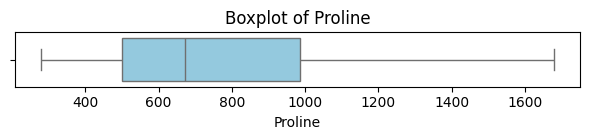

Column: Proline
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


In [10]:
descriptor_cols = ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
                   'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins',
                   'Color_Intensity', 'Hue', 'OD280', 'Proline']

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > threshold]
    return outliers

for col in descriptor_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    detect_outliers = detect_outliers_iqr(df, col)
    z_score_outliers = detect_outliers_zscore(df, col)

    print(f'Column: {col}')
    print(f'IQR Method - Number of outliers: {len(detect_outliers)}')
    print(f'Z-Score Method - Number of outliers: {len(z_score_outliers)}')

In [11]:
# Phương án 1: Loại bỏ outliers
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

df_no_outliers = remove_outliers_iqr(df, descriptor_cols)
print(f"Số dòng ban đầu: {len(df)}")
print(f"Số dòng sau khi loại outliers: {len(df_no_outliers)}")

Số dòng ban đầu: 178
Số dòng sau khi loại outliers: 161


In [15]:
from sklearn.preprocessing import StandardScaler
df_clean = remove_outliers_iqr(df, descriptor_cols)

# Lấy dữ liệu đã xử lý outliers
X = df_clean[descriptor_cols].values

# Chuẩn hóa (Z-score standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dữ liệu sau chuẩn hóa:")
print(f"Mean: {X_scaled.mean(axis=0)}")  # Gần 0
print(f"Std: {X_scaled.std(axis=0)}")    # Gần 1

Dữ liệu sau chuẩn hóa:
Mean: [ 3.08931624e-15 -1.76532357e-16  7.61295788e-16 -4.41330892e-17
 -2.42731990e-16 -1.32399268e-16 -2.64798535e-16 -3.08931624e-16
  0.00000000e+00  2.35836195e-16  8.82661784e-16 -1.32399268e-16
 -1.76532357e-16]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa
X = df_clean[descriptor_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chuyển thành DataFrame để dễ xem
df_scaled = pd.DataFrame(X_scaled, 
                         columns=descriptor_cols,
                         index=df_clean.index)

print("="*80)
print("DỮ LIỆU SAU CHUẨN HÓA (DataFrame)")
print("="*80)
print(df_scaled)

print("\n" + "="*80)
print("5 DÒNG ĐẦU TIÊN")
print("="*80)
print(df_scaled.head())

print("\n" + "="*80)
print("5 DÒNG CUỐI CÙNG")
print("="*80)
print(df_scaled.tail())

DỮ LIỆU SAU CHUẨN HÓA (DataFrame)
      Alcohol  Malic_Acid       Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    1.515163   -0.579166  0.270936     -1.248144   2.298023       0.828643   
1    0.209648   -0.512507 -0.931537     -2.732175   0.114047       0.589411   
2    0.158948    0.039806  1.266087     -0.236305   0.194935       0.828643   
3    1.692612   -0.350622  0.561189     -0.843409   1.165591       2.503264   
4    0.260347    0.258826  2.095379      0.573166   1.570031       0.828643   
..        ...         ...       ...           ...        ...            ...   
172  1.426439    0.182645  0.478259      0.235886  -0.613945      -0.957620   
174  0.463146    1.515815  0.478259      1.247725   0.275823      -0.766235   
175  0.298372    1.868152 -0.433962      0.235886   1.731807      -1.101159   
176  0.171623    0.258826  0.022149      0.235886   1.731807      -1.005466   
177  1.388414    1.696745  1.556339      1.753645  -0.209505      -0.367515   

     Flavanoids  

SO SÁNH MDS VỚI CÁC METRIC KHOẢNG CÁCH KHÁC NHAU


📏 METRIC: Euclidean (L2)
   🔄 q=2 chiều... ✓ Norm: 21.87% | SStress: 32.26% | Kém
   🔄 q=3 chiều... ✓ Norm: 14.03% | SStress: 20.96% | Trung bình
   🔄 q=4 chiều... ✓ Norm: 9.87% | SStress: 15.28% | Chấp nhận
   🔄 q=5 chiều... ✓ Norm: 7.02% | SStress: 10.79% | Chấp nhận
   🔄 q=6 chiều... ✓ Norm: 5.26% | SStress: 8.15% | Chấp nhận
   🔄 q=7 chiều... ✓ Norm: 3.86% | SStress: 6.07% | Tốt
   🔄 q=8 chiều... ✓ Norm: 2.97% | SStress: 4.87% | Tốt
   🔄 q=9 chiều... ✓ Norm: 2.25% | SStress: 3.75% | Xuất sắc
   🔄 q=10 chiều... ✓ Norm: 1.63% | SStress: 2.80% | Xuất sắc

📏 METRIC: Manhattan (L1)
   🔄 q=2 chiều... ✓ Norm: 19.89% | SStress: 27.95% | Trung bình
   🔄 q=3 chiều... ✓ Norm: 12.99% | SStress: 18.70% | Trung bình
   🔄 q=4 chiều... ✓ Norm: 9.34% | SStress: 13.82% | Chấp nhận
   🔄 q=5 chiều... ✓ Norm: 7.15% | SStress: 10.76% | Chấp nhận
   🔄 q=6 chiều... ✓ Norm: 5.91% | SStress: 9.27% | Chấp nhận
   🔄 q=7 chiều... ✓ Norm: 5.10% | SStress: 8.28%

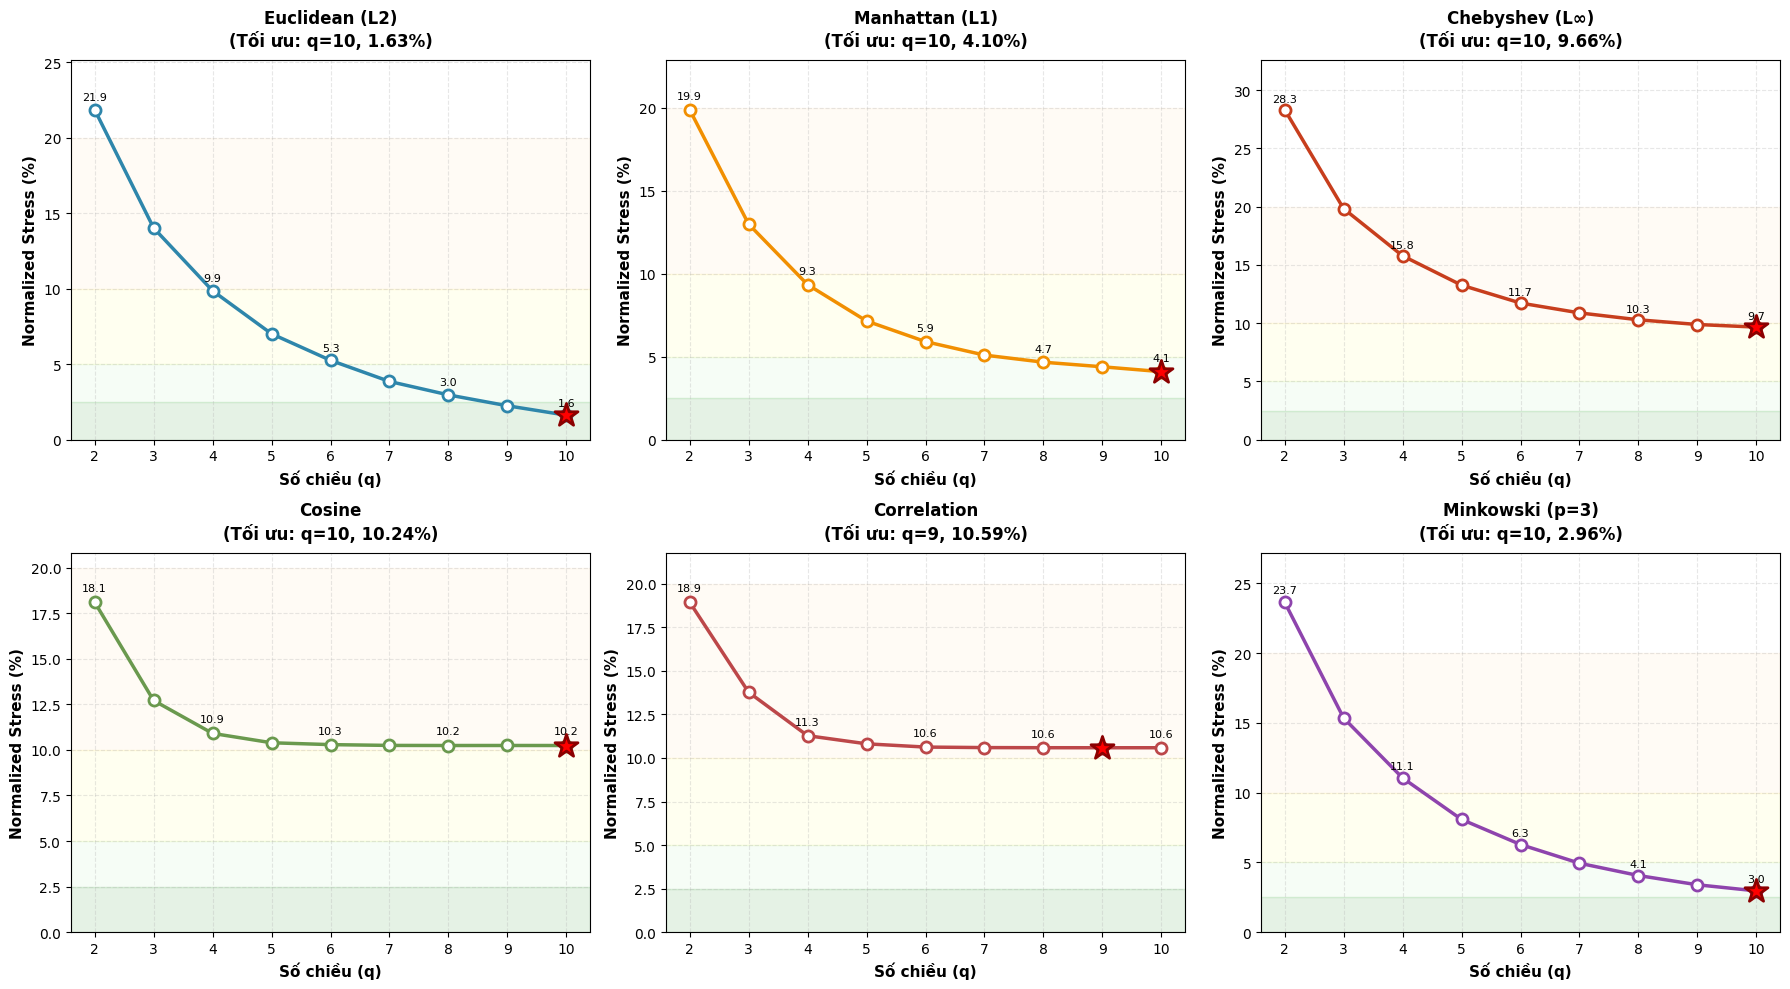


✓ Đồ thị đã được lưu: mds_metrics_comparison.png

KẾT LUẬN

🏆 METRIC TỐT NHẤT (trung bình):
   • Metric:            Euclidean (L2)
   • Stress trung bình: 7.64%

📊 STRESS TRUNG BÌNH CỦA TỪNG METRIC:
   • Euclidean (L2)           :   7.64%
   • Manhattan (L1)           :   8.17%
   • Chebyshev (L∞)           :  14.41%
   • Cosine                   :  11.49%
   • Correlation              :  11.98%
   • Minkowski (p=3)          :   8.87%



In [30]:
from sklearn.manifold import smacof
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.stdout.flush()

# ===== HÀM TÍNH CÁC CHỈ SỐ STRESS =====
def calculate_normalized_stress(distance_matrix, mds_coords):
    """Normalized Stress (Stress-1)"""
    d_original = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]
    d_embedded = pairwise_distances(mds_coords)[np.triu_indices_from(distance_matrix, k=1)]
    
    numerator = np.sum((d_original - d_embedded) ** 2)
    denominator = np.sum(d_original ** 2)
    normalized_stress = np.sqrt(numerator / denominator)
    
    return normalized_stress

def calculate_sstress(distance_matrix, mds_coords):
    """SStress (S-Stress)"""
    d_original = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]
    d_embedded = pairwise_distances(mds_coords)[np.triu_indices_from(distance_matrix, k=1)]
    
    numerator = np.sum((d_original**2 - d_embedded**2) ** 2)
    denominator = np.sum(d_original ** 4)
    sstress = np.sqrt(numerator / denominator)
    
    return sstress

def evaluate_quality(norm_stress):
    """Đánh giá chất lượng"""
    if norm_stress < 0.025:
        return "Xuất sắc"
    elif norm_stress < 0.05:
        return "Tốt"
    elif norm_stress < 0.10:
        return "Chấp nhận"
    elif norm_stress < 0.20:
        return "Trung bình"
    else:
        return "Kém"

# ===== DANH SÁCH CÁC METRIC =====
metrics = {
    'euclidean': 'Euclidean (L2)',
    'manhattan': 'Manhattan (L1)',
    'chebyshev': 'Chebyshev (L∞)',
    'cosine': 'Cosine',
    'correlation': 'Correlation',
    'minkowski': 'Minkowski (p=3)'
}

# ===== SO SÁNH CÁC METRIC =====
all_results = {}

print("=" * 100)
print("SO SÁNH MDS VỚI CÁC METRIC KHOẢNG CÁCH KHÁC NHAU")
print("=" * 100)
print()

for metric_name, metric_label in metrics.items():
    print(f"\n{'='*100}")
    print(f"📏 METRIC: {metric_label}")
    print(f"{'='*100}")
    
    # Tính ma trận khoảng cách với metric này
    if metric_name == 'minkowski':
        distance_matrix = pairwise_distances(X_scaled, metric='minkowski', p=3)
    else:
        distance_matrix = pairwise_distances(X_scaled, metric=metric_name)
    
    results = []
    
    # Chạy MDS cho các số chiều từ 2-10
    for q in range(2, 11):
        print(f"   🔄 q={q} chiều...", end=" ")
        
        try:
            X_mds, raw_stress = smacof(
                distance_matrix,
                n_components=q,
                metric=True,
                max_iter=300,
                verbose=0,
                random_state=42,
                n_init=4,
                eps=1e-6
            )
            
            norm_stress = calculate_normalized_stress(distance_matrix, X_mds)
            norm_stress_pct = norm_stress * 100
            
            sstress = calculate_sstress(distance_matrix, X_mds)
            sstress_pct = sstress * 100
            
            quality = evaluate_quality(norm_stress)
            
            results.append({
                'q': q,
                'Normalized_Stress_%': norm_stress_pct,
                'SStress_%': sstress_pct,
                'Quality': quality
            })
            
            print(f"✓ Norm: {norm_stress_pct:.2f}% | SStress: {sstress_pct:.2f}% | {quality}")
            
        except Exception as e:
            print(f"✗ Lỗi: {str(e)}")
            continue
    
    all_results[metric_label] = pd.DataFrame(results)
    sys.stdout.flush()

# ===== BẢNG SO SÁNH TÓM TẮT =====
print("\n" + "=" * 100)
print("BẢNG SO SÁNH TÓM TẮT - NORMALIZED STRESS (%) CHO MỖI METRIC")
print("=" * 100)

# Tạo bảng pivot
summary_data = {}
for metric_label, df in all_results.items():
    summary_data[metric_label] = df.set_index('q')['Normalized_Stress_%']

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(float_format=lambda x: f'{x:.2f}'))

# Tìm metric tốt nhất cho mỗi số chiều
print("\n" + "=" * 100)
print("METRIC TỐI ƯU CHO MỖI SỐ CHIỀU")
print("=" * 100)

for q in range(2, 11):
    best_metric = summary_df.loc[q].idxmin()
    best_stress = summary_df.loc[q].min()
    print(f"q={q:2d} chiều: {best_metric:25s} (Stress: {best_stress:6.2f}%)")

# ===== VẼ ĐỒ THỊ SO SÁNH =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#2E86AB', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#8E44AD']

for idx, (metric_label, df) in enumerate(all_results.items()):
    ax = axes[idx]
    
    dimensions = df['q'].values
    norm_stress = df['Normalized_Stress_%'].values
    
    # Vẽ đường cong
    ax.plot(dimensions, norm_stress, 
            marker='o', linewidth=2.5, markersize=8,
            color=colors[idx], label=metric_label,
            markerfacecolor='white', markeredgewidth=2,
            markeredgecolor=colors[idx])
    
    # Vùng chất lượng
    ax.axhspan(0, 2.5, alpha=0.1, color='green')
    ax.axhspan(2.5, 5.0, alpha=0.08, color='lightgreen')
    ax.axhspan(5.0, 10.0, alpha=0.06, color='yellow')
    ax.axhspan(10.0, 20.0, alpha=0.04, color='orange')
    
    # Đánh dấu điểm tối ưu
    optimal_idx = df['Normalized_Stress_%'].idxmin()
    optimal_q = int(df.loc[optimal_idx, 'q'])
    optimal_stress = df.loc[optimal_idx, 'Normalized_Stress_%']
    
    ax.scatter([optimal_q], [optimal_stress],
              s=300, color='red', marker='*',
              edgecolors='darkred', linewidths=2, zorder=5)
    
    # Thêm giá trị
    for dim, stress in zip(dimensions[::2], norm_stress[::2]):  # Chỉ hiện mỗi 2 điểm
        ax.text(dim, stress + 0.5, f'{stress:.1f}',
               ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Số chiều (q)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Normalized Stress (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_label}\n(Tối ưu: q={optimal_q}, {optimal_stress:.2f}%)', 
                fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(dimensions)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(norm_stress) * 1.15)

plt.tight_layout()
plt.savefig('mds_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 100)
print("✓ Đồ thị đã được lưu: mds_metrics_comparison.png")
print("=" * 100)

# ===== KẾT LUẬN =====
print("\n" + "=" * 100)
print("KẾT LUẬN")
print("=" * 100)

# Tìm metric tốt nhất tổng thể (trung bình qua các số chiều)
avg_stress = summary_df.mean()
best_overall_metric = avg_stress.idxmin()
best_avg_stress = avg_stress.min()

print(f"\n🏆 METRIC TỐT NHẤT (trung bình):")
print(f"   • Metric:            {best_overall_metric}")
print(f"   • Stress trung bình: {best_avg_stress:.2f}%")

print(f"\n📊 STRESS TRUNG BÌNH CỦA TỪNG METRIC:")
for metric_label, stress in avg_stress.items():
    print(f"   • {metric_label:25s}: {stress:6.2f}%")

print("\n" + "=" * 100)